In [ ]:
import seaborn as sns
import pandas as pd
mpg_df = sns.load_dataset('mpg')
mpg_df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


#**Đặt vấn đề: Giữa trọng lượng và số dặm xe đi được trên một gallon có mối liên hệ hay không**

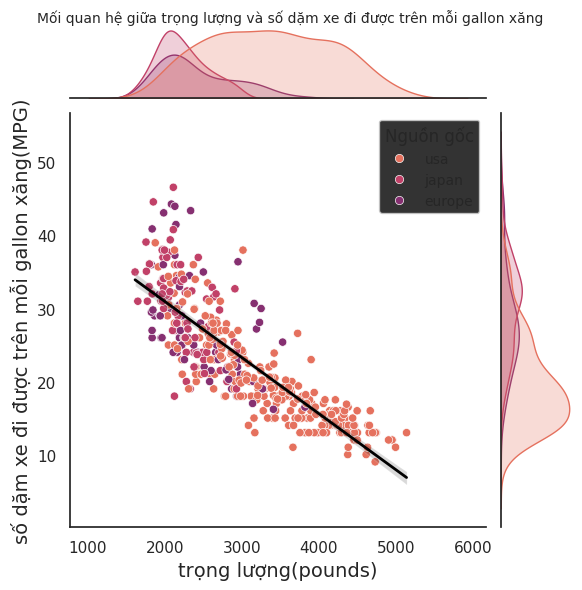

In [ ]:
import seaborn as sns
g = sns.jointplot(data=mpg_df, x="weight", y="mpg", hue="origin",palette="flare")
g.fig.suptitle("Mối quan hệ giữa trọng lượng và số dặm xe đi được trên mỗi gallon xăng", fontsize=10)
sns.regplot(data=mpg_df, x="weight", y="mpg", scatter=False, ax=g.ax_joint, color='black', line_kws={"linewidth": 2})
g.set_axis_labels("trọng lượng(pounds)", "số dặm xe đi được trên mỗi gallon xăng(MPG)", fontsize=14)
g.fig.subplots_adjust(top=0.95)
g.ax_joint.legend(title="Nguồn gốc", title_fontsize=12, loc='upper right', fontsize=10)



#Nhận xét:
##Hình ảnh thể hiện mối quan hệ giữa trọng lượng của xe (đơn vị pounds) và mức tiêu thụ nhiên liệu (MPG - miles per gallon) của xe, phân loại theo nguồn gốc xuất xứ (USA, Japan, Europe).
###Rút ra ý nghĩa:

####Mối quan hệ nghịch biến: Đường hồi quy tuyến tính có độ dốc âm cho thấy mối quan hệ nghịch biến giữa trọng lượng xe và mức tiêu thụ nhiên liệu tức xe càng nặng, mức tiêu thụ nhiên liệu càng cao (MPG càng thấp). Điều này hợp lý vì xe nặng cần nhiều năng lượng hơn để di chuyển.

####Phân bố theo nguồn gốc: Ba nhóm xe (USA, Japan, Europe) có phân bố khác nhau trên biểu đồ. Có thể thấy Mỹ sản xuất xe trọng lượng lớn nhiều hơn hẳn Nhật Bản và Châu Âu, kéo theo mức tiêu thụ nhiên liệu cao của các xe đến từ Mỹ, từ đó dẫn đến số dặm đi được trên một gallon đến từ xe Mỹ thấp.

####Sự phân tán: Các điểm dữ liệu không nằm hoàn toàn trên đường hồi quy, cho thấy có các yếu tố khác ngoài trọng lượng ảnh hưởng đến mức tiêu thụ nhiên liệu. Những yếu tố này có thể bao gồm: Số xi-lanh của động cơ, dung tích động cơ, mã lực của động cơ, gia tốc,...


#**Đặt vấn đề: Giữa mpg và horsepower có mối liên hệ như thế nào?**

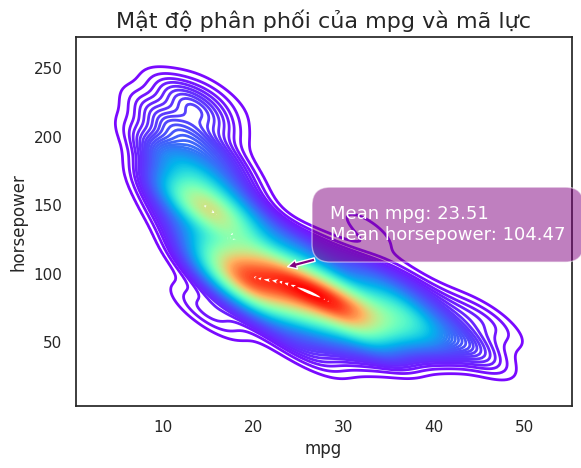

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("white")
mpg_sns = sns.load_dataset("mpg")

sns.kdeplot(
    data=mpg_sns, x="mpg", y="horsepower",
    fill=False, thresh=0, levels=100, cmap="rainbow", linewidths=2,
)

plt.title("Mật độ phân phối của mpg và mã lực", fontsize=16)

mean_mpg = mpg_sns['mpg'].mean()
mean_hp = mpg_sns['horsepower'].mean()

plt.annotate(
    f"Mean mpg: {mean_mpg:.2f}\nMean horsepower: {mean_hp:.2f}",
    xy=(mean_mpg, mean_hp),
    xytext=(mean_mpg + 5, mean_hp + 20),
    arrowprops=dict(facecolor='purple', arrowstyle="simple"),
    fontsize=13,
    color="white",
    bbox=dict(facecolor='purple', alpha=0.5, boxstyle="round,pad=1")
)
plt.show()

#Nhận xét: Thật sự có mối liên hệ giữa mpg và horsepower, cụ thể:
##Dựa vào mật độ phân phối, có thể thấy rằng giữa mpg và horsepower có mối quan hệ nghịch biến
##Tại khu vực mật độ cao (Các khu vực có màu đỏ, cam hoặc vàng trong biểu đồ): Phần lớn dữ liệu tập trung ở các giá trị mpg thấp (khoảng từ 10 đến 25) và horsepower thấp (khoảng 50 đến 150), cho thấy hầu hết các xe trong bộ dữ liệu có hiệu suất nhiên liệu ở mức trung bình và động cơ không quá mạnh.
##Tại khu vực mật độ thấp (Các khu vực có màu xanh dương hoặc tím): Càng có nhiều horsepower, mpg có xu hướng giảm, điều này hợp lý với các xe mạnh mẽ hơn nhưng lại tiêu thụ nhiều nhiên liệu hơn.
## Kết luận: Các xe có mã lực mạnh mẽ thường không tiết kiệm nhiên liệu bằng các xe có mã lực nhỏ hơn.

#**Đặt vấn đề: Có sự khác biệt rõ rệt nào về số lượng xi lanh giữa các xe đến từ các khu vực khác nhau (USA, Japan, Europe)? Chúng ta có thể thấy gì về mức độ tiết kiệm nhiên liệu (MPG) của các xe đến từ các quốc gia khác nhau?**

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

fig = px.sunburst(
    mpg_df,
    path=['origin', 'cylinders'],
    values='mpg',
    color='mpg',
    color_continuous_scale='Viridis',
    title="Phân phối xe theo nguồn gốc và số xy-lanh"
)

fig.update_traces(
    hovertemplate='<b>Origin:</b> %{label}<br>' +
                  '<b>Cylinders:</b> %{parent}<br>' +
                  '<b>MPG:</b> %{value:.2f}',
    textinfo='label+percent parent',
    marker=dict(
        line=dict(color='black', width=1)
    )
)

fig.update_layout(
    title=dict(
        text="Phân phối xe theo nguồn gốc và số xy-lanh",
        font=dict(size=20, family='Arial', color='darkblue'),
        x=0.5,
    ),
    coloraxis_colorbar=dict(
        title="Miles per Gallon",
        thicknessmode="pixels", thickness=15,
        lenmode="pixels", len=300,
        yanchor="middle", y=0.5,
        ticks="outside", ticksuffix=" MPG",
        dtick=5
    ),
    margin=dict(t=50, l=0, r=0, b=0),
    sunburstcolorway=["#636efa", "#ef553b", "#00cc96", "#ab63fa", "#ffa15a"]
)


fig.show()



#Nhận xét:
##**Mối quan hệ giữa Origin và Cylinders?**
##USA: Các xe đến từ Mỹ có xu hướng sử dụng động cơ với số xi lanh lớn (8 xi lanh), đặc biệt trong các nhóm xe có MPG thấp. Phản ánh việc các xe của Mỹ thường có động cơ mạnh mẽ, công suất lớn nhưng tiêu thụ nhiên liệu cao hơn.
##Japan: Các xe đến từ Nhật Bản chủ yếu sử dụng động cơ với số xi lanh thấp, thường là 4 hoặc 6 xi lanh. Các xe này thường tiết kiệm nhiên liệu hơn và có MPG cao. Điều này cho thấy Nhật Bản ưu tiên việc tiết kiệm nhiên liệu và hiệu quả vận hành, đặc biệt với các động cơ nhỏ hơn.
##Europe: Các xe từ Châu Âu có sự phân phối số xi lanh khá đa dạng, bao gồm cả các xe sử dụng động cơ 4, 6, và 8 xi lanh. Điều này có thể chỉ ra rằng các thương hiệu xe ở Châu Âu cung cấp cả các lựa chọn tiết kiệm nhiên liệu và các dòng xe có công suất cao.

##**Chúng ta có thể thấy gì về mức độ tiết kiệm nhiên liệu (MPG) của các xe đến từ các quốc gia khác nhau?**
##**Xe đến từ Nhật Bản (Japan):**
##Mức độ MPG cao: Các xe đến từ Nhật Bản có xu hướng có giá trị MPG cao, chứng tỏ chúng tiết kiệm nhiên liệu rất tốt. Điều này có thể giải thích bởi việc các nhà sản xuất Nhật Bản thường sử dụng động cơ nhỏ hơn, tối ưu hóa hiệu quả nhiên liệu.

##**Xe đến từ Mỹ (USA):**
##Mức độ MPG thấp: Các xe đến từ Mỹ có mức MPG thấp hơn so với các xe từ Nhật Bản. Điều này có thể do các xe của Mỹ thường sử dụng động cơ lớn, công suất mạnh mẽ hơn, dẫn đến tiêu thụ nhiên liệu cao hơn. Những dòng xe này, mặc dù mạnh mẽ và có khả năng vận hành tốt trên các cung đường dài hoặc khi kéo tải nặng, nhưng lại không tiết kiệm nhiên liệu như các dòng xe nhỏ của Nhật Bản.

##**Xe đến từ Châu Âu (Europe):**
##Phân phối MPG khá đồng đều: Các xe từ Châu Âu có sự phân phối MPG khá đồng đều. Một số dòng xe có MPG cao (tiết kiệm nhiên liệu tốt), nhưng cũng có một số dòng xe có MPG thấp hơn, điều này có thể phản ánh sự đa dạng về loại động cơ và mục đích sử dụng của các dòng xe này. Châu Âu có cả những mẫu xe nhỏ tiết kiệm nhiên liệu, nhưng cũng có các xe mạnh mẽ hơn hoặc xe thể thao tiêu thụ nhiều nhiên liệu hơn.

#**Đặt vấn đề: Có hay không mối quan hệ giữa số xi lanh và hiệu quả nhiên liệu (MPG):**

In [ ]:
import plotly.express as px
import seaborn as sns
import pandas as pd
mpg_df = sns.load_dataset('mpg')
fig = px.scatter(mpg_df, x="cylinders", y="mpg", color='cylinders',
                 color_continuous_scale='plotly3',
                 title="Mối quan hệ giữa số xi lanh và hiệu quả nhiên liệu (MPG)",  # Tiêu đề
                 labels={"cylinders": "Số xi lanh", "mpg": "Hiệu quả nhiên liệu (MPG)"},  # Nhãn trục
                 hover_data=["name", "origin"])
fig.show()

#Nhận xét:
## Sơ lược về biểu đồ:
###1. Trục x (Số xi lanh - Cylinders)
###2. Trục y (Hiệu quả nhiên liệu - MPG)
###3. Phân phối màu sắc: Các điểm màu sắc từ màu sáng (ví dụ: vàng) đại diện cho những xe có số xi lanh thấp (4 xi lanh). Các điểm màu sắc tối hơn (ví dụ: màu đỏ đậm) đại diện cho những xe có số xi lanh lớn (6, 8 xi lanh).
##Đưa ra kết luận:
##Có mối quan hệ nghịch chiều giữa số xi lanh và hiệu quả nhiên liệu (MPG), cụ thể như sau:
##Biểu đồ cho thấy các xe có số xi lanh thấp (4 xi lanh) thường có hiệu quả nhiên liệu (MPG) cao hơn so với các xe có số xi lanh lớn hơn (6, 8 xi lanh).
##- MPG (Miles per Gallon) là chỉ số đo lường sự hiệu quả trong việc tiêu thụ nhiên liệu của mỗi chiếc xe. Các giá trị MPG cao có nghĩa là xe tiết kiệm nhiên liệu hơn.
##-Xe 4 xi lanh có hiệu quả nhiên liệu cao nhất, với nhiều điểm dữ liệu nằm ở phía trên biểu đồ (MPG > 20).
##-Xe 6 xi lanh có hiệu quả nhiên liệu trung bình (MPG trong khoảng 15-25), nhưng có một số xe vẫn đạt mức MPG cao.
##-Xe 8 xi lanh có hiệu quả nhiên liệu thấp hơn (MPG < 20), điều này hợp lý vì động cơ lớn tiêu thụ nhiều nhiên liệu hơn và có công suất mạnh mẽ.
##Có thể lý giải mối quan hệ này vì động cơ với ít xi lanh tiêu thụ ít nhiên liệu hơn và có xu hướng tiết kiệm hơn.
##Biểu đồ cũng cung cấp thông tin về origin (nguồn gốc của xe):
###Xe từ Japan thường sử dụng động cơ nhỏ (4 xi lanh), giúp tiết kiệm nhiên liệu.
###Xe từ USA thường có động cơ lớn hơn (6-8 xi lanh), điều này giải thích lý do vì sao MPG của các xe từ Mỹ thấp hơn.
###Xe từ Europe có sự phân bổ tương đối đồng đều giữa các xe có 4 và 6 xi lanh, phản ánh sự đa dạng về loại xe của các nhà sản xuất châu Âu, với các dòng xe vừa tiết kiệm nhiên liệu vừa mạnh mẽ.

#**Theo thời gian, các nhà sản xuất xe từ ba nước Mỹ, Châu Âu và Nhật Bản liệu có tăng cường sản xuất các dòng xe tiết kiệm nhiên liệu?**

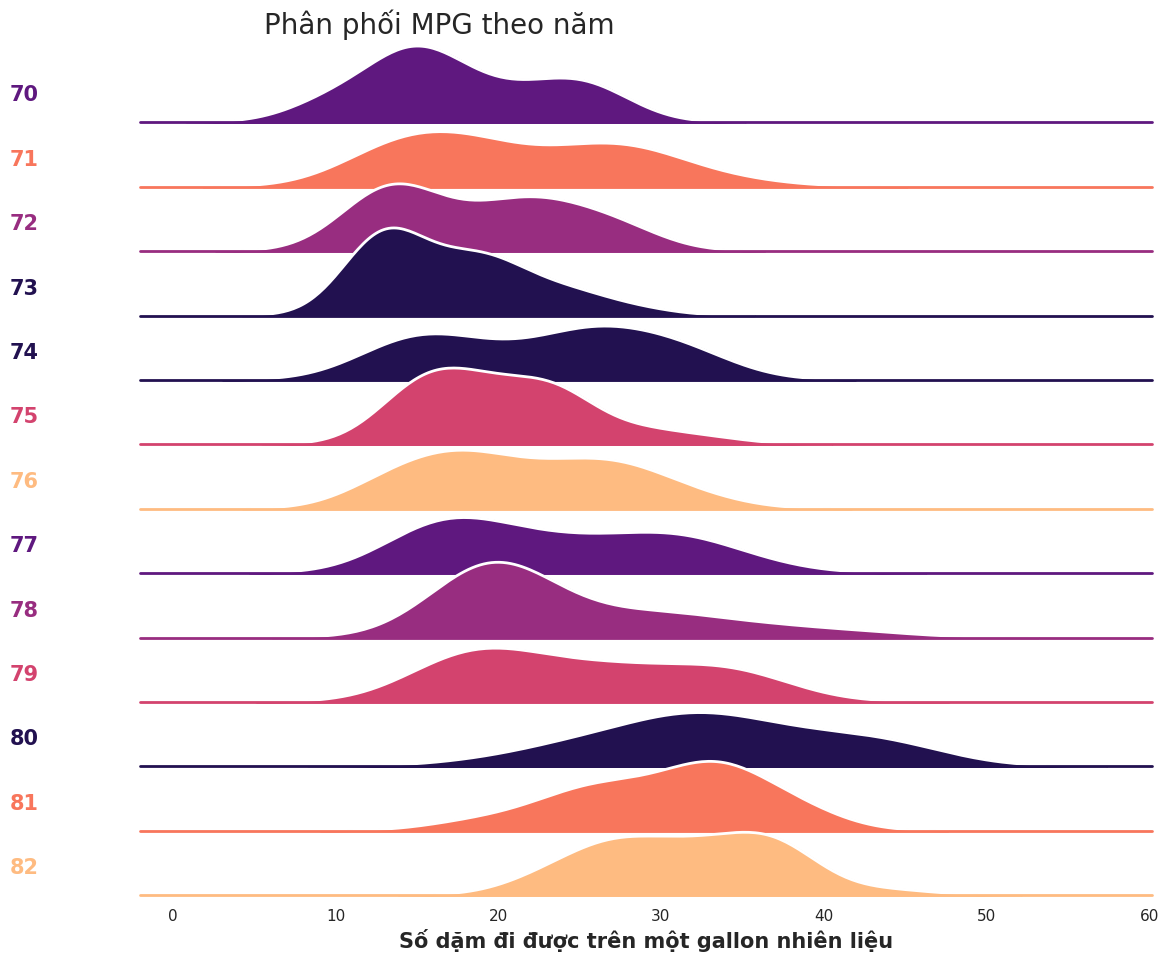

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
mpg_sns = sns.load_dataset("mpg")
mpg_sns['mean_mpg'] = mpg_sns.groupby('model_year')['mpg'].transform('mean')
pal = sns.color_palette("magma")
g = sns.FacetGrid(mpg_sns, row='model_year', hue='mean_mpg', aspect=15, height=0.75, palette=pal)
g.map(sns.kdeplot, 'mpg', bw_adjust=1, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, 'mpg', bw_adjust=1, clip_on=False, color="w", lw=2)
g.map(plt.axhline, y=0, lw=2, clip_on=False)

for i, ax in enumerate(g.axes.flat):
    ax.text(-10, 0.02, str(70 + i), fontweight='bold', fontsize=15, color=ax.lines[-1].get_color())

g.fig.subplots_adjust(hspace=-0.3)

g.set_titles("")
g.set(yticks=[])
g.set_ylabels("")
g.despine(bottom=True, left=True)

plt.xlabel('Số dặm đi được trên một gallon nhiên liệu', fontweight='bold', fontsize=15)
g.fig.suptitle('Phân phối MPG theo năm', ha='right', fontsize=20, fontweight=20)

plt.show()


#**Nhận xét:**
## Sơ lược về biểu đồ:
###1. Trục x: Biểu thị giá trị của Miles per Gallon (MPG)
###2. Trục y: Biểu diễn mật độ xác suất (density), cho biết khả năng xuất hiện của các giá trị MPG cụ thể ở các năm mẫu xe khác nhau.
###3. FacetGrid: Mỗi model_year có một biểu đồ riêng biệt, cho phép so sánh sự phân phối MPG qua các năm
###4. Màu sắc: Màu sắc càng sáng thì giá trị trung bình MPG càng cao, và ngược lại.
##Đưa ra kết luận:
##Các năm gần nhau (lấy ví dụ là 1970 và 1971) có thể có sự phân phối MPG tương đối giống nhau. Tuy nhiên, có sự khác biệt rõ rệt giữa các model_year
##Các năm gần về sau: Sự phân bố MPG có xu hướng cao hơn, tức là xe hơi sản xuất sau này có hiệu quả nhiên liệu tốt hơn. Thể hiện qua các năm về sau (như 1978-1982) có màu sáng hơn, cho thấy MPG cao hơn, tức là xe hơi hiệu quả hơn về mặt tiêu thụ nhiên liệu.
##Các năm về trước (như 1970, 1971): Có xu hướng có MPG thấp hơn, cho thấy xe hơi sản xuất trong các năm này tiêu thụ nhiều nhiên liệu hơn và ít hiệu quả hơn. Thể hiện qua các năm về trước (như 1970) thường có màu sắc tối, tương ứng với MPG thấp.
##Nhận xét chung:
##Tăng trưởng MPG: Có thể nhận thấy rằng sau những năm 1970, MPG của các xe hơi sản xuất bắt đầu cải thiện, điển hình là trong khoảng 1973-1975, với các đỉnh điểm lớn hơn.
##Xu hướng chung: Biểu đồ cho thấy xu hướng chung là MPG tăng dần qua các năm, phản ánh sự cải tiến trong công nghệ động cơ, sử dụng các vật liệu nhẹ hơn và sự quan tâm đến bảo vệ môi trường và tiết kiệm nhiên liệu trong ngành công nghiệp ô tô

#**phân tích sự thay đổi của các đặc điểm xe hơi qua các năm?**

In [ ]:
!pip install vega_datasets
import seaborn as sns
import pandas as pd
import altair as alt
mpg_sns = sns.load_dataset("mpg")
select_year = alt.selection_single(
    name='Select', fields=['model_year'], init={'model_year': 70},
    bind=alt.binding_range(min=70, max=82, step= 1)
)
alt.Chart(mpg_sns).mark_point(filled=True).encode(
    alt.X('displacement'),
    alt.Y('horsepower'),
    alt.Size('mpg'),
    alt.Color('origin'),
    alt.OpacityValue(0.7),
    tooltip = [alt.Tooltip('name'),
               alt.Tooltip('displacement'),
               alt.Tooltip('horsepower'),
               alt.Tooltip('mpg')
              ]
).add_selection(
    select_year
).transform_filter(
    select_year
)


/usr/local/lib/python3.10/dist-packages/altair/utils/core.py:384: FutureWarning:

the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.

/usr/local/lib/python3.10/dist-packages/altair/utils/core.py:384: FutureWarning:

the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.



alt.Chart(...)

#**Nhận xét:**
## Sơ lược về biểu đồ:
###1. Trục X: displacement - Dung tích động cơ của các xe hơi (tính bằng cubic inch).
###2. Trục Y: horsepower - Công suất động cơ (tính bằng mã lực).
###3. Size (kích thước điểm): mpg - Hiệu quả nhiên liệu của xe, với kích thước của điểm tỷ lệ với giá trị mpg. Xe có hiệu quả nhiên liệu cao sẽ có điểm lớn hơn.
###4. Color (màu sắc): Màu sắc theo origin - Nguồn gốc của xe (USA, Europe, hoặc Japan)
##Nhận xét chung:
##Nhìn chung, xe có dung tích động cơ lớn thường có công suất cao.
##Những chiếc xe có dung tích động cơ lớn hơn thường có công suất động cơ mạnh hơn, nhưng đồng thời cũng tiêu thụ nhiều nhiên liệu hơn.
##Các xe có hiệu quả nhiên liệu cao (MPG lớn) sẽ có điểm lớn hơn. Một mẫu xe có dung tích động cơ và công suất cao nhưng có MPG thấp (hiệu quả nhiên liệu thấp) có thể được thể hiện bằng điểm nhỏ hơn.
##Thông thường, xe đến từ Japan có MPG cao hơn vì chúng thường sử dụng động cơ nhỏ, tiết kiệm nhiên liệu. Xe từ USA có thể có MPG thấp hơn, do sử dụng động cơ lớn với công suất mạnh mẽ hơn.
##Kết luận:
##năm 1970-1975, chúng ta có thể thấy xe từ thời kỳ này có công suất cao nhưng hiệu quả nhiên liệu thấp, còn các năm sau đó có thể có sự cải thiện về hiệu quả nhiên liệu.

#**Câu hỏi: Các nước sẽ sản xuất cho tệp khách hàng nào?**

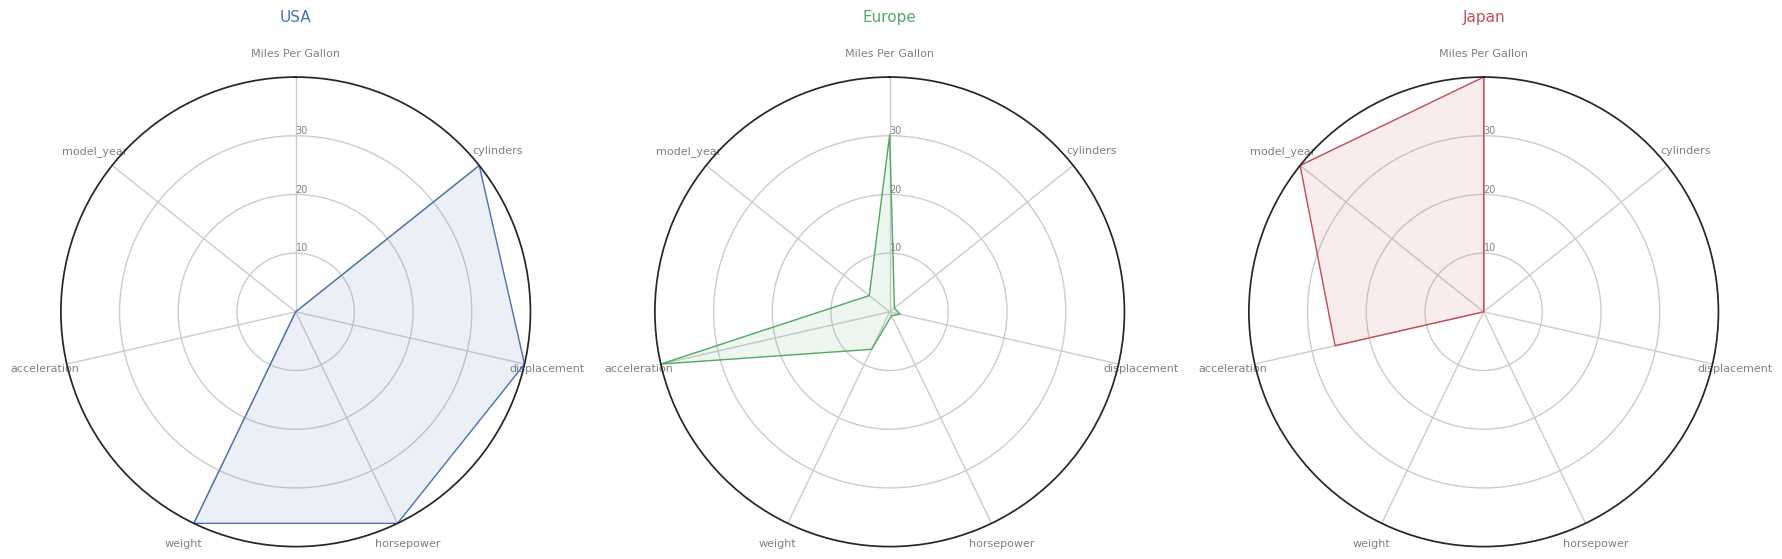

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from math import pi

mpg_sns = sns.load_dataset("mpg")

USA = mpg_sns[mpg_sns['origin'] == 'usa'].mean(numeric_only=True)
Europe = mpg_sns[mpg_sns['origin'] == 'europe'].mean(numeric_only=True)
Japan = mpg_sns[mpg_sns['origin'] == 'japan'].mean(numeric_only=True)


df = pd.DataFrame({
    'group': ['USA', 'Europe', 'Japan'],
    'Miles Per Gallon': [USA['mpg'], Europe['mpg'], Japan['mpg']],
    'cylinders': [USA['cylinders'], Europe['cylinders'], Japan['cylinders']],
    'displacement': [USA['displacement'], Europe['displacement'], Japan['displacement']],
    'horsepower': [USA['horsepower'], Europe['horsepower'], Japan['horsepower']],
    'weight': [USA['weight'], Europe['weight'], Japan['weight']],
    'acceleration': [USA['acceleration'], Europe['acceleration'], Japan['acceleration']],
    'model_year': [USA['model_year'], Europe['model_year'], Japan['model_year']]
})


df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda x: (x - x.min()) / (x.max() - x.min()) * 40)


categories = list(df)[1:]
N = len(categories)


def create_spider_plot(ax, values, title, color):

    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]


    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, color='grey', size=8)


    ax.set_rlabel_position(0)
    ax.set_yticks([10, 20, 30])
    ax.set_yticklabels(["10", "20", "30"], color="grey", size=7)
    ax.set_ylim(0, 40)

    values += values[:1]
    ax.plot(angles, values, linewidth=1, linestyle='solid', color=color)
    ax.fill(angles, values, color=color, alpha=0.1)

    ax.set_title(title, size=11, color=color, y=1.1)

fig, axs = plt.subplots(1, 3, subplot_kw=dict(polar=True), figsize=(18, 6))

values_usa = df.iloc[0, 1:].values.flatten().tolist()
create_spider_plot(axs[0], values_usa, "USA", 'b')

values_europe = df.iloc[1, 1:].values.flatten().tolist()
create_spider_plot(axs[1], values_europe, "Europe", 'g')

values_japan = df.iloc[2, 1:].values.flatten().tolist()
create_spider_plot(axs[2], values_japan, "Japan", 'r')

plt.tight_layout()
plt.show()


#**Japan: Nhật Bản**
## mile per gallon cao: Nhật Bản chuyên sản xuất ra những chiếc xe tối ưu mức tiêu thụ nhiên liệu cũng như tính kinh tế nói chung.
##việc model_year của Nhật Bản chiếm ưu thế đồng nghĩa với việc Nhật Bản sản xuất rất nhiều xe mới. Cung nhiều đồng nghĩa với cầu nhiều, như vậy hoàn toàn có thế tin tưởng rằng xe hơi của Nhật Bản được rất nhiều người tin dùng, tức là có độ tin cậy cao.
##"acceleration" được đo bằng thời gian để tăng từ 0 đến 60 mph, với đơn vị là giây. Giá trị càng thấp xe tăng tốc càng nhanh. Nói đơn giản "acceleration" là gia tốc - đại lượng vật lý đặc trưng cho sự thay đổi của vận tốc theo thời gian. khi lăn bánh, bản thân xe sẽ chịu ảnh hưởng của rất nhiều lực cản. Trên lý thuyết, nếu chiếc xe chuyển động đều, gia tốc sẽ = 0, hạn chế được tối đa các lực cản nói trên. Trên thực tế,  khi lưu thông trên đường, không thể nào điều khiển xe lăn bánh với vận tốc đều được, mà phải có lúc nhanh lúc chậm tùy tình trạng giao thông trên đường (khi đạp phanh hoặc đạp ga thì gia tốc sẽ xuất hiện). Như vậy, để hạn chế những lực cản nói trên khi lái xe nên điều khiển xe trên đường làm sao để đại lượng gia tốc là nhỏ nhất và là một hằng số (gia tốc không đổi). Có nghĩa là:
###Khi tăng tốc: nhịp nhẹ và đều chân ga để xe tăng tốc với vận tốc nhanh dần đều (lúc này gia tốc sẽ nhỏ và là một hằng số).

###Khi giảm tốc phải nhịp phanh nhẹ nhàng để vận tốc giảm chậm dần đều (lúc này gia tốc cũng sẽ nhỏ và là một hằng số).

####Như vậy, với chỉ số gia tốc nằm ở mức trung bình, Nhật Bản rất chú tâm vào độ an toàn và trải nghiệm của hành khách cũng như người cầm lái

#--> Tóm lại, tệp khách hàng mà Nhật Bản hướng đến là những người chú trọng sự an toàn cũng như quan tâm đến sự tiết kiệm nhiên liệu và chi phí vận hành của xe, coi trọng độ tin cậy và độ bền của xe và những người quan tâm đến độ nhận diện của hãng xe.


#**Europe: Châu Âu**
##mile per gallon: Nằm ở mức trung bình, chứng tỏ số dặm trung bình trên một gallon nhiên liệu thấp hơn Nhật Bản, tức là độ tiêu thụ nhiên liệu nhiều hơn
##"acceleration" cao: Xe của các hãng đến từ Châu Âu có khả năng tăng tốc nhanh, acceleration cao còn phản ánh các dòng xe châu Âu thường được trang bị công nghệ hiện đại để tối ưu hóa khả năng tăng tốc, từ động cơ tăng áp (turbocharged engines) đến hệ thống truyền động điện lai hoặc hoàn toàn bằng điện (electric & hybrid drivetrains)

## Model_year: thấp, chứng tỏ các nhà sản xuất xe châu Âu thường thiết kế những chiếc xe có độ bền cao và chất lượng vượt thời gian. Điều này khiến các dòng xe đời cũ vẫn duy trì được giá trị sử dụng và được khách hàng tin tưởng. Các thương hiệu châu Âu phổ biến trong thị trường xe cũ nhờ giá trị thương hiệu, độ bền và cảm giác lái tốt.

##displacement: thường đề cập đến dung tích xi-lanh của động cơ (displacement), tính bằng đơn vị lít (L) hoặc cubic centimeters (cc). Trong đồ thị của Châu Âu, displacement có phần nhỉnh hơn đôi chút đồng nghĩa với khả năng sản sinh công suất cao hơn vì động cơ có thể đốt cháy nhiều nhiên liệu và không khí hơn trong mỗi chu trình. Điều này thường dẫn đến mức tiêu thụ nhiên liệu cao hơn, lý giải vì sao mile per gallon bị giảm đi.
#--> Tóm lại Châu Âu hướng đến tệp khách hàng đam mê cảm giác lái cùng với hiệu suất cao, ưu tiên chất lượng xe cũng như giá trị thương hiệu, những người ưu chuộng xe sang trọng, thích tìm đến sự hoài cổ và vẫn giữ được công nghệ tiên. Đối tượng họ nhắm đến cũng là những người ở tầng lớp trung lưu và thượng.

#**USA: Mỹ**
##Cylinders: số xi-lanh của động cơ. Các loại xe khác nhau có số xi-lanh khác nhau, tùy thuộc vào mục đích sử dụng và thiết kế động cơ. Việc Mỹ chiếm ưu thế về số xi lanh, chứng tỏ họ muốn tăng công suất động cơ, khả năng tăng tốc và tải trọng. Điều này lý giải lí do vì sao Mỹ không thể chiếm ưu thế về mile per gallon.

##displacement: Cùng với số xi lanh nhiều thì dung tích xi lanh của các hãng đến từ Mỹ trội hoàn toàn so với hai nước còn lại chứng tỏ họ chú trọng đến sức mạnh và công suất cực cao, giúp xe Mỹ vượt trội về khả năng kéo tải, tăng tốc và chạy trên các cung đường dài, đặc biệt là địa hình phức tạp hoặc nhu cầu vận chuyển nặng, phù hợp với các con đường và bãi đỗ xe ở Mỹ.

##horsepower: Cao phản ánh khả năng động cơ tạo ra lực mạnh mẽ hơn, giúp xe Mỹ có hiệu suất vận hành vượt trội, đặc biệt trong các lĩnh vực như tăng tốc nhanh, kéo tải nặng, vận hành ổn định ở tốc độ cao.

##Trọng lượng xe (weight): Cao thường đi kèm với kích thước xe lớn, lý giải phần nào kéo tải mạnh, phù hợp nhu cầu vận chuyển nặng.

#--> Như vậy, tệp khách hàng Mỹ muốn hướng đến là những người cần xe cho mục đích công việc và vận chuyển nặng, các đại gia đình cần xe rộng rãi, những người ưu thích xe có hiệu suất cao, đa dụng, bền bỉ.

Đã xuất biểu đồ ra file Bieu_do_tang_truong_HDC.png thành công!


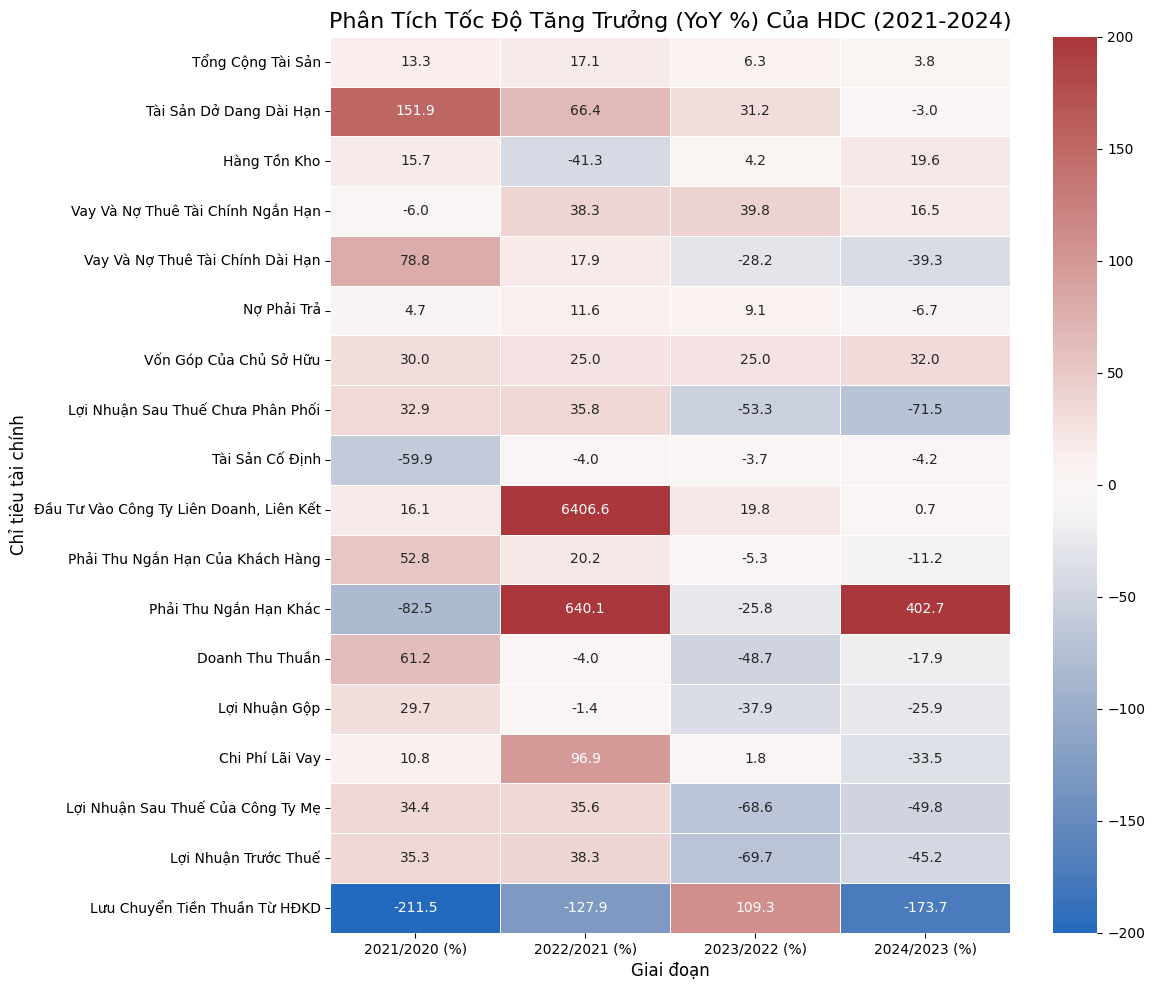

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chuẩn bị dữ liệu từ bảng của bạn (Đã chuẩn hóa)
data = {
    'Chỉ tiêu': [
        'Tổng Cộng Tài Sản', 'Tài Sản Dở Dang Dài Hạn', 'Hàng Tồn Kho',
        'Vay Và Nợ Thuê Tài Chính Ngắn Hạn', 'Vay Và Nợ Thuê Tài Chính Dài Hạn', 'Nợ Phải Trả',
        'Vốn Góp Của Chủ Sở Hữu', 'Lợi Nhuận Sau Thuế Chưa Phân Phối', 'Tài Sản Cố Định',
        'Đầu Tư Vào Công Ty Liên Doanh, Liên Kết', 'Phải Thu Ngắn Hạn Của Khách Hàng', 'Phải Thu Ngắn Hạn Khác',
        'Doanh Thu Thuần', 'Lợi Nhuận Gộp', 'Chi Phí Lãi Vay',
        'Lợi Nhuận Sau Thuế Của Công Ty Mẹ', 'Lợi Nhuận Trước Thuế', 'Lưu Chuyển Tiền Thuần Từ HĐKD'
    ],
    '2021/2020 (%)': [
        13.34, 151.89, 15.69, -5.98, 78.76, 4.69, 29.99, 32.90, -59.94,
        16.14, 52.82, -82.49, 61.19, 29.70, 10.79, 34.40, 35.34, -211.49
    ],
    '2022/2021 (%)': [
        17.08, 66.36, -41.28, 38.34, 17.88, 11.56, 24.99, 35.80, -3.99,
        6406.60, 20.25, 640.13, -4.01, -1.36, 96.89, 35.57, 38.30, -127.89
    ],
    '2023/2022 (%)': [
        6.27, 31.24, 4.19, 39.79, -28.16, 9.10, 24.99, -53.26, -3.73,
        19.80, -5.28, -25.80, -48.73, -37.92, 1.76, -68.60, -69.68, 109.29
    ],
    '2024/2023 (%)': [
        3.80, -2.99, 19.64, 16.51, -39.33, -6.65, 32.01, -71.52, -4.17,
        0.65, -11.20, 402.74, -17.92, -25.93, -33.53, -49.82, -45.23, -173.67
    ]
}

df = pd.DataFrame(data)
df.set_index('Chỉ tiêu', inplace=True)

# 2. Vẽ biểu đồ nhiệt
plt.figure(figsize=(12, 10))
sns.heatmap(
    df,
    annot=True,
    fmt=".1f",
    linewidths=.5,
    cmap='vlag',
    center=0,
    vmin=-200,
    vmax=200
)

# 3. Tùy chỉnh tiêu đề và hiển thị
plt.title('Phân Tích Tốc Độ Tăng Trưởng (YoY %) Của HDC (2021-2024)', fontsize=16)
plt.xlabel('Giai đoạn', fontsize=12)
plt.ylabel('Chỉ tiêu tài chính', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()

# ===================================================================
# 4. LƯU BIỂU ĐỒ RA FILE PDF
# ===================================================================
# Đặt dòng này ngay trước plt.show()
plt.savefig('Bieu_do_tang_truong_HDC.png', dpi=300, bbox_inches='tight')
print("Đã xuất biểu đồ ra file Bieu_do_tang_truong_HDC.png thành công!")

# 5. Hiển thị biểu đồ (tùy chọn)
plt.show()